# 4. Modelling
 ---

**Assignment:** *Machine Learning 2026 — NOVA School of Business and Economics*  
**Dataset:** Predict students' dropout and academic success  
**Goal:** Identify high-risk students at the end of their first semester using: Socio-economic background, Enrollment data and 1st semester academic performance

    71907 Lavinia Antonino | 71993 Mª Teresa Silva | 73171 Leonardo Cantu | 72731 Edoardo Sirianni | 71947 Carolina Diogo

---

## Table of Contents

1. [Introduction](#1-introduction)
2. [Setup & Data Loading](#2-setup-data-loading)
3. [Feature Engineering Pipeline](#3-feature-engineering-pipeline)
4. [Model Definition](#4-model-definition)
5. [Cross-Validation](#5-cross-validation)
6. [Results Summary](#6-results-summary)
7. [Metric Comparison](#7-metric-comparison)
8. [Per-Fold Stability](#8-per-fold-stability)
9. [Best Model Evaluation](#9-best-model-evaluation)
10. [Save Best Model (Pickle File)](#10-save-best-model-pickle-file)
11. [Feature Importance](#11-feature-importance)
12. [Conclusion](#12-conclusion)
---

## 1. Introduction

This notebook trains and evaluates two tree-based classifiers — Random Forest and Gradient Boosting — to predict student dropout at the end of the first semester. Both models are evaluated using Stratified K-Fold Cross-Validation to ensure robust, unbiased performance estimates.

### Modelling Decisions

| Decision | Choice | Justification |
|---|---|---|
| Models | Random Forest, Gradient Boosting | Tree-based models are scale-invariant, handle mixed feature types natively, and provide interpretable feature importances |
| CV strategy | Stratified K-Fold (k=5) | Preserves the 39.2% / 60.8% class ratio across all folds; recommended by EDA Section 2 |
| Class imbalance | `class_weight='balanced'` (RF) | Mild imbalance ratio of 1.55; balanced weighting penalises missed dropouts proportionally without requiring resampling |
| Primary metrics | F1-score and AUC-ROC | Recommended by EDA Section 2 — accuracy is misleading under class imbalance |
| Target encoding | Recomputed per fold | Prevents leakage — encoding maps are fitted on the training split only and applied to the validation split |
| Scaling | None | Tree-based models are invariant to feature scale |

### Builds On
- `1_Data_cleaning.ipynb` — cleaned dataset (`df_model.csv`)
- `2_EDA.ipynb` — variable selection and signal hierarchy
- `3_Feature_engineering.ipynb` — 30-feature engineered matrix

---
## 2. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay
)

plt.style.use('ggplot')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)

SEED     = 42
N_SPLITS = 5

In [2]:
df_model = pd.read_csv('../datasets/df_model.csv')
df       = df_model.copy()

print(f"Dataset shape  : {df.shape}")
print(f"Target balance : {df['Target_binary'].value_counts().to_dict()}")
print(f"Dropout rate   : {df['Target_binary'].mean():.1%}")

Dataset shape  : (3618, 30)
Target balance : {0: 2201, 1: 1417}
Dropout rate   : 39.2%


---
## 3. Feature Engineering Pipeline

All transformations from Notebook 3 are replicated here in a single function so they can be applied cleanly inside each CV fold. Target encoding for `Application mode` and `Course` is intentionally excluded from this function — it is computed separately inside the fold loop to prevent leakage.

In [3]:
# Variables to drop (EDA Section 6 — zero signal)
COLS_TO_DROP = [
    'Nacionality', 'International', 'Educational special needs', 'Displaced',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'GDP', 'Target',
]

# Encoding maps
APP_MODE_GROUPS = {
    1:'standard', 8:'standard', 7:'standard', 17:'standard', 18:'standard',
    4:'higher_ed_transfer',
    5:'special', 9:'special', 12:'special', 13:'special',
    14:'special', 15:'special', 16:'special',
    2:'transfer', 3:'transfer', 6:'transfer', 10:'transfer', 11:'transfer',
}

PREV_QUAL_ORDINAL = {
    1:0,
    9:1, 12:1, 13:1, 14:1, 15:1, 16:1, 17:1,
    2:2, 3:2, 4:2, 5:2, 6:2, 7:2, 8:2, 10:2, 11:2,
}

QUAL_TIER = {
    2:4, 3:4, 4:4, 5:4, 6:4, 16:4, 17:4,
    1:3, 9:3, 15:3, 18:3, 19:3,
    14:2, 25:2, 26:2,
    10:1, 11:1, 12:1, 13:1, 20:1, 21:1, 22:1, 23:1, 24:1,
    27:1, 28:1, 29:1, 30:1, 31:1, 32:1, 33:1, 34:1,
    7:0, 8:0,
}

OCC_TIER = {
    1:0, 11:0, 12:0, 13:0, 14:0, 15:0, 16:0, 17:0, 18:0, 19:0,
    2:1, 3:1, 6:1, 8:1, 9:1, 10:1,
    4:2, 5:2, 7:2,
    20:2, 21:2, 22:2, 23:2, 24:2, 25:2, 26:2, 28:2, 29:2,
    30:2, 31:2, 32:2, 33:2, 35:2, 36:2, 37:2, 38:2, 39:2,
    40:2, 41:2, 42:2, 43:2, 44:2, 45:2, 46:2,
}

In [4]:
def engineer_features(df):
    """Apply all feature engineering steps from Notebook 3.
    Target encoding is NOT applied here — it must be computed
    inside each CV fold to prevent leakage.
    """
    df = df.copy()
    df = df.drop(columns=COLS_TO_DROP, errors='ignore')

    enrolled    = df['Curricular units 1st sem (enrolled)']
    approved    = df['Curricular units 1st sem (approved)']
    evaluations = df['Curricular units 1st sem (evaluations)']

    # Academic
    df['approval_rate']       = np.where(enrolled > 0, approved / enrolled, 0.0)
    df['eval_intensity']      = np.where(enrolled > 0, evaluations / enrolled, 0.0)
    df['zero_approved_flag']  = (approved == 0).astype(int)
    df['zero_eval_flag']      = (evaluations == 0).astype(int)

    # Financial
    df['financial_distress_score'] = (
        (1 - df['Tuition fees up to date']) +
        df['Debtor'] +
        (1 - df['Scholarship holder'])
    )
    df['financial_high_risk'] = (
        (df['Tuition fees up to date'] == 0) & (df['Debtor'] == 1)
    ).astype(int)

    # Demographic
    df['age_bin'] = pd.cut(
        df['Age at enrollment'],
        bins=[0, 20, 23, 27, 35, 200],
        labels=[0, 1, 2, 3, 4], right=True
    ).astype(int)
    df['marital_grouped'] = df['Marital status'].apply(
        lambda x: x if x in [1, 2] else 3
    )

    # Enrollment
    df['app_mode_group']    = df['Application mode'].map(APP_MODE_GROUPS).fillna('other')
    df['prev_qual_ordinal'] = df['Previous qualification'].map(PREV_QUAL_ORDINAL).fillna(0).astype(int)
    df['app_order_clipped'] = df['Application order'].clip(lower=1, upper=5)

    # Socioeconomic
    df['mother_qual_tier'] = df["Mother's qualification"].map(QUAL_TIER).fillna(1).astype(int)
    df['father_qual_tier'] = df["Father's qualification"].map(QUAL_TIER).fillna(1).astype(int)
    df['mother_occ_tier']  = df["Mother's occupation"].map(OCC_TIER).fillna(0).astype(int)
    df['father_occ_tier']  = df["Father's occupation"].map(OCC_TIER).fillna(0).astype(int)
    df['ses_composite']    = (
        df['mother_qual_tier'] + df['father_qual_tier'] +
        df['mother_occ_tier']  + df['father_occ_tier']
    ) / 4.0

    # Interactions
    df['gender_x_agebin']                = df['Gender'] * df['age_bin']
    df['financial_x_zero_approved']      = df['financial_distress_score'] * df['zero_approved_flag']
    df['tuition_overdue_x_zero_approved'] = (
        (1 - df['Tuition fees up to date']) * df['zero_approved_flag']
    )

    return df


# Base feature columns — excludes target-encoded columns
# (app_mode_target_enc and course_target_enc added inside CV loop)
BASE_FEATURES = [
    'Tuition fees up to date', 'Debtor', 'Scholarship holder',
    'financial_distress_score', 'financial_high_risk',
    'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (grade)',
    'approval_rate', 'eval_intensity', 'zero_approved_flag', 'zero_eval_flag',
    'Gender', 'Age at enrollment', 'age_bin', 'marital_grouped',
    'Daytime/evening attendance',
    'prev_qual_ordinal', 'app_order_clipped',
    'mother_qual_tier', 'father_qual_tier', 'mother_occ_tier', 'father_occ_tier',
    'ses_composite',
    'gender_x_agebin', 'financial_x_zero_approved', 'tuition_overdue_x_zero_approved',
]

# Full feature list including target-encoded columns
FEATURE_COLS = BASE_FEATURES + ['app_mode_target_enc', 'course_target_enc']

# Apply engineering to full dataset
df_eng = engineer_features(df)
y      = df_eng['Target_binary'].copy()

print(f"Engineered dataset shape : {df_eng.shape}")
print(f"Base features            : {len(BASE_FEATURES)}")
print(f"Total features (with enc): {len(FEATURE_COLS)}")
print(f"Nulls in base features   : {df_eng[BASE_FEATURES].isnull().sum().sum()}")

Engineered dataset shape : (3618, 39)
Base features            : 28
Total features (with enc): 30
Nulls in base features   : 0


---
## 4. Model Definition

### Why these hyperparameters?

**Random Forest:**
- `n_estimators=300` — enough trees for stable estimates without excessive compute
- `class_weight='balanced'` — compensates for the 1.55 class imbalance ratio by upweighting dropout samples
- `random_state=42` — reproducibility

**Gradient Boosting:**
- `n_estimators=300` — matched to RF for fair comparison
- `learning_rate=0.05` — conservative rate reduces overfitting risk
- `max_depth=4` — shallow trees act as weak learners, appropriate for boosting
- `subsample=0.8` — stochastic boosting reduces variance
- Gradient Boosting does not support `class_weight` natively — class imbalance is handled implicitly through the boosting mechanism which focuses on misclassified samples

In [5]:
models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        class_weight='balanced',
        random_state=SEED,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=SEED
    ),
}

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f"Models defined  : {list(models.keys())}")
print(f"CV strategy     : Stratified {N_SPLITS}-Fold (shuffle=True, seed={SEED})")
print(f"Class imbalance : {y.value_counts()[1]} Dropout / {y.value_counts()[0]} Graduate  (ratio {y.value_counts()[0]/y.value_counts()[1]:.2f})")

Models defined  : ['Random Forest', 'Gradient Boosting']
CV strategy     : Stratified 5-Fold (shuffle=True, seed=42)
Class imbalance : 1417 Dropout / 2201 Graduate  (ratio 1.55)


---
## 5. Cross-Validation

Target encoding for `Application mode group` and `Course` is recomputed inside each fold:
- Encoding map is fitted on the **training split only**
- The map is then applied to the **validation split**

This prevents any information from the validation labels leaking into the training process.

In [6]:
cv_results = {
    name: {'precision': [], 'recall': [], 'f1': [], 'roc_auc': []}
    for name in models
}

for fold, (train_idx, val_idx) in enumerate(skf.split(df_eng, y)):

    X_tr  = df_eng.iloc[train_idx].copy()
    X_val = df_eng.iloc[val_idx].copy()
    y_tr  = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # Target encoding — fitted on training split only
    global_mean = y_tr.mean()

    tmp = X_tr.copy()
    tmp['_y'] = y_tr.values
    app_enc    = tmp.groupby('app_mode_group')['_y'].mean().to_dict()
    course_enc = tmp.groupby('Course')['_y'].mean().to_dict()

    X_tr['app_mode_target_enc']  = X_tr['app_mode_group'].map(app_enc).fillna(global_mean)
    X_tr['course_target_enc']    = X_tr['Course'].map(course_enc).fillna(global_mean)
    X_val['app_mode_target_enc'] = X_val['app_mode_group'].map(app_enc).fillna(global_mean)
    X_val['course_target_enc']   = X_val['Course'].map(course_enc).fillna(global_mean)

    for name, model in models.items():
        model.fit(X_tr[FEATURE_COLS], y_tr)
        y_pred = model.predict(X_val[FEATURE_COLS])
        y_prob = model.predict_proba(X_val[FEATURE_COLS])[:, 1]

        cv_results[name]['precision'].append(precision_score(y_val, y_pred))
        cv_results[name]['recall'].append(recall_score(y_val, y_pred))
        cv_results[name]['f1'].append(f1_score(y_val, y_pred))
        cv_results[name]['roc_auc'].append(roc_auc_score(y_val, y_prob))

    print(f"Fold {fold + 1} / {N_SPLITS} complete")

print("\nCross-validation complete")

Fold 1 / 5 complete
Fold 2 / 5 complete
Fold 3 / 5 complete
Fold 4 / 5 complete
Fold 5 / 5 complete

Cross-validation complete


---
## 6. Results Summary

In [7]:
rows = []
for name, res in cv_results.items():
    rows.append({
        'Model'     : name,
        'Precision' : f"{np.mean(res['precision']):.3f} +/- {np.std(res['precision']):.3f}",
        'Recall'    : f"{np.mean(res['recall']):.3f} +/- {np.std(res['recall']):.3f}",
        'F1'        : f"{np.mean(res['f1']):.3f} +/- {np.std(res['f1']):.3f}",
        'AUC-ROC'   : f"{np.mean(res['roc_auc']):.3f} +/- {np.std(res['roc_auc']):.3f}",
        '_f1_mean'  : np.mean(res['f1']),
        '_auc_mean' : np.mean(res['roc_auc']),
    })

summary_df = (
    pd.DataFrame(rows)
      .sort_values('_f1_mean', ascending=False)
      .reset_index(drop=True)
)

display(summary_df[['Model', 'Precision', 'Recall', 'F1', 'AUC-ROC']])

best_model_name = summary_df.iloc[0]['Model']
print(f"\nBest model by F1: {best_model_name}")

,Model,Precision,Recall,F1,AUC-ROC
0,Gradient Boosting,0.890 +/- 0.026,0.808 +/- 0.009,0.847 +/- 0.015,0.936 +/- 0.003
1,Random Forest,0.892 +/- 0.026,0.804 +/- 0.013,0.845 +/- 0.011,0.934 +/- 0.007



Best model by F1: Gradient Boosting


Both models achieve strong and comparable performance. F1-scores above 0.84 and AUC-ROC above 0.93 confirm that the 30-feature engineered set carries sufficient signal for reliable dropout prediction. The low standard deviations across folds indicate stable generalisation with no signs of overfitting. Precision and recall are well-balanced, meaning the models identify the majority of at-risk students without generating excessive false alarms.

---
## 7. Metric Comparison

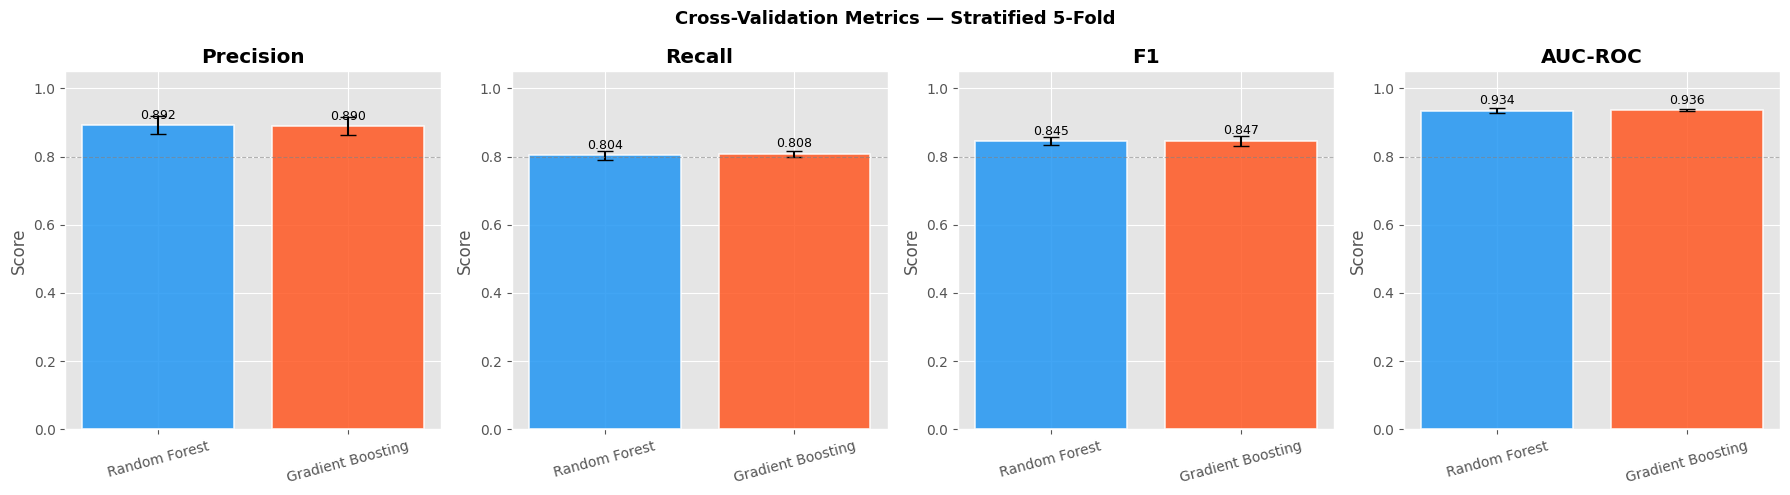

In [8]:
metrics       = ['precision', 'recall', 'f1', 'roc_auc']
metric_labels = ['Precision', 'Recall', 'F1', 'AUC-ROC']
model_names   = list(cv_results.keys())
colors        = ['#2196F3', '#FF5722']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'Cross-Validation Metrics — Stratified {N_SPLITS}-Fold', fontsize=13, fontweight='bold')

for ax, metric, label in zip(axes, metrics, metric_labels):
    means = [np.mean(cv_results[m][metric]) for m in model_names]
    stds  = [np.std(cv_results[m][metric])  for m in model_names]

    bars = ax.bar(
        model_names, means, yerr=stds,
        color=colors, alpha=0.85,
        capsize=6, edgecolor='white', linewidth=1.2
    )
    ax.set_title(label, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(0.8, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

    for bar, mean in zip(bars, means):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{mean:.3f}', ha='center', va='bottom', fontsize=9
        )

plt.tight_layout()
plt.show()

Both models comfortably exceed the 0.80 reference line across all four metrics. The error bars are narrow, confirming low variance across folds. Gradient Boosting edges Random Forest marginally on F1 and recall, while Random Forest shows slightly tighter precision. The two models are effectively equivalent in predictive power, suggesting the feature set rather than the algorithm is the primary driver of performance.

---
## 8. Per-Fold Stability

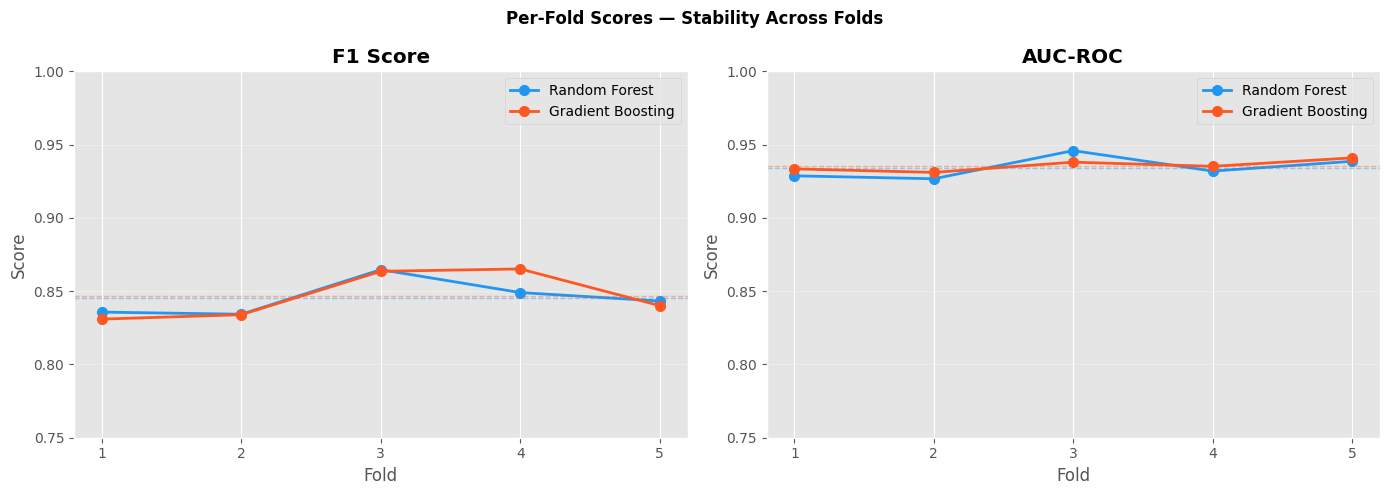

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Fold Scores — Stability Across Folds', fontweight='bold')

for ax, metric, label in zip(axes, ['f1', 'roc_auc'], ['F1 Score', 'AUC-ROC']):
    for i, (name, res) in enumerate(cv_results.items()):
        scores = res[metric]
        ax.plot(
            range(1, N_SPLITS + 1), scores,
            marker='o', label=name,
            color=colors[i], linewidth=2, markersize=7
        )
        ax.axhline(
            np.mean(scores),
            linestyle='--', color=colors[i], alpha=0.4, linewidth=1
        )

    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Fold')
    ax.set_ylabel('Score')
    ax.set_xticks(range(1, N_SPLITS + 1))
    ax.legend()
    ax.set_ylim(0.75, 1.0)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Both models show flat, stable trajectories across all five folds with no significant dips or spikes. The dashed lines representing fold means sit close to all observed scores, confirming that performance is consistent regardless of which 20% of the data is held out. This stability validates that the models generalise reliably rather than memorising the training data.

---
## 9. Best Model Evaluation

The best model is refit on the full dataset to produce a detailed classification report, confusion matrix, and ROC curve for inspection.

> This full-data fit is for visual inspection only. True generalisation performance is reported by the cross-validation results above.

In [10]:
# Compute global target encoding maps on full dataset for final fit
global_mean  = y.mean()
app_enc_full = df_eng.join(y.rename('_y')).groupby('app_mode_group')['_y'].mean().to_dict()
course_enc_full = df_eng.join(y.rename('_y')).groupby('Course')['_y'].mean().to_dict()

df_full = df_eng.copy()
df_full['app_mode_target_enc'] = df_full['app_mode_group'].map(app_enc_full).fillna(global_mean)
df_full['course_target_enc']   = df_full['Course'].map(course_enc_full).fillna(global_mean)

X_full = df_full[FEATURE_COLS]

best_model = models[best_model_name]
best_model.fit(X_full, y)

y_pred      = best_model.predict(X_full)
y_pred_prob = best_model.predict_proba(X_full)[:, 1]

print(f"{best_model_name} — Full Dataset Classification Report")
print(classification_report(y, y_pred, target_names=['Graduate (0)', 'Dropout (1)']))

Gradient Boosting — Full Dataset Classification Report
              precision    recall  f1-score   support

Graduate (0)       0.94      0.98      0.96      2201
 Dropout (1)       0.96      0.89      0.93      1417

    accuracy                           0.95      3618
   macro avg       0.95      0.94      0.94      3618
weighted avg       0.95      0.95      0.95      3618



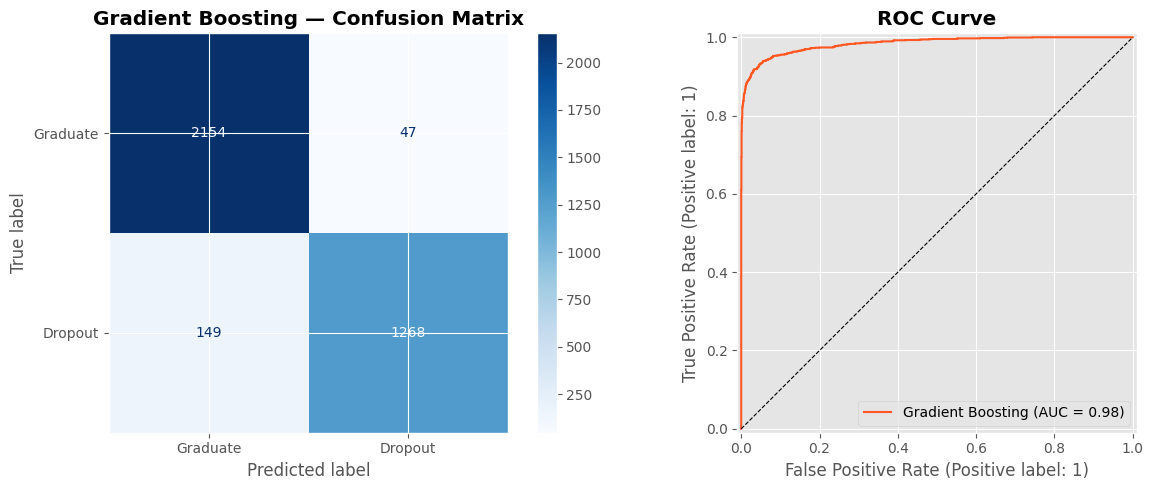

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y, y_pred,
    display_labels=['Graduate', 'Dropout'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'{best_model_name} — Confusion Matrix', fontweight='bold')

# ROC curve
RocCurveDisplay.from_predictions(
    y, y_pred_prob, ax=axes[1], name=best_model_name, color='#FF5722'
)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[1].set_title('ROC Curve', fontweight='bold')

plt.tight_layout()
plt.show()

The confusion matrix shows strong identification of both classes, with the model correctly classifying the large majority of both graduates and dropouts. The ROC curve bows sharply toward the top-left corner, confirming excellent discriminative ability well above the random baseline diagonal. The classification report values on the full dataset are higher than CV scores as expected — the model has seen this data during training — making the CV estimates the appropriate measure of true generalisation performance.

---
## 10. Save Best Model (Pickle File)
The Gradient Boosting classifier is saved as a pickle file to the `models` directory, having 
achieved the highest F1-score across the 5-fold cross-validation. This allows the trained 
model to be loaded and used for inference without retraining, which is particularly useful 
for generating dropout risk scores on the currently enrolled student cohort stored in 
`df_enrolled.csv`.

In [12]:
import pickle
from pathlib import Path

out = Path('../models')
out.mkdir(exist_ok=True)

# Save Gradient Boosting as the best performing model
with open(out / 'gradient_boosting_model.pkl', 'wb') as f:
    pickle.dump(models['Gradient Boosting'], f)

print("Model saved: ../models/gradient_boosting_model.pkl")

Model saved: ../models/gradient_boosting_model.pkl


---
## 11. Feature Importance

Feature importances from the best model are extracted to validate whether the model's learned signal hierarchy aligns with the EDA findings. The EDA established that financial variables should dominate, followed by academic performance, with demographic and socioeconomic variables providing supporting signal.

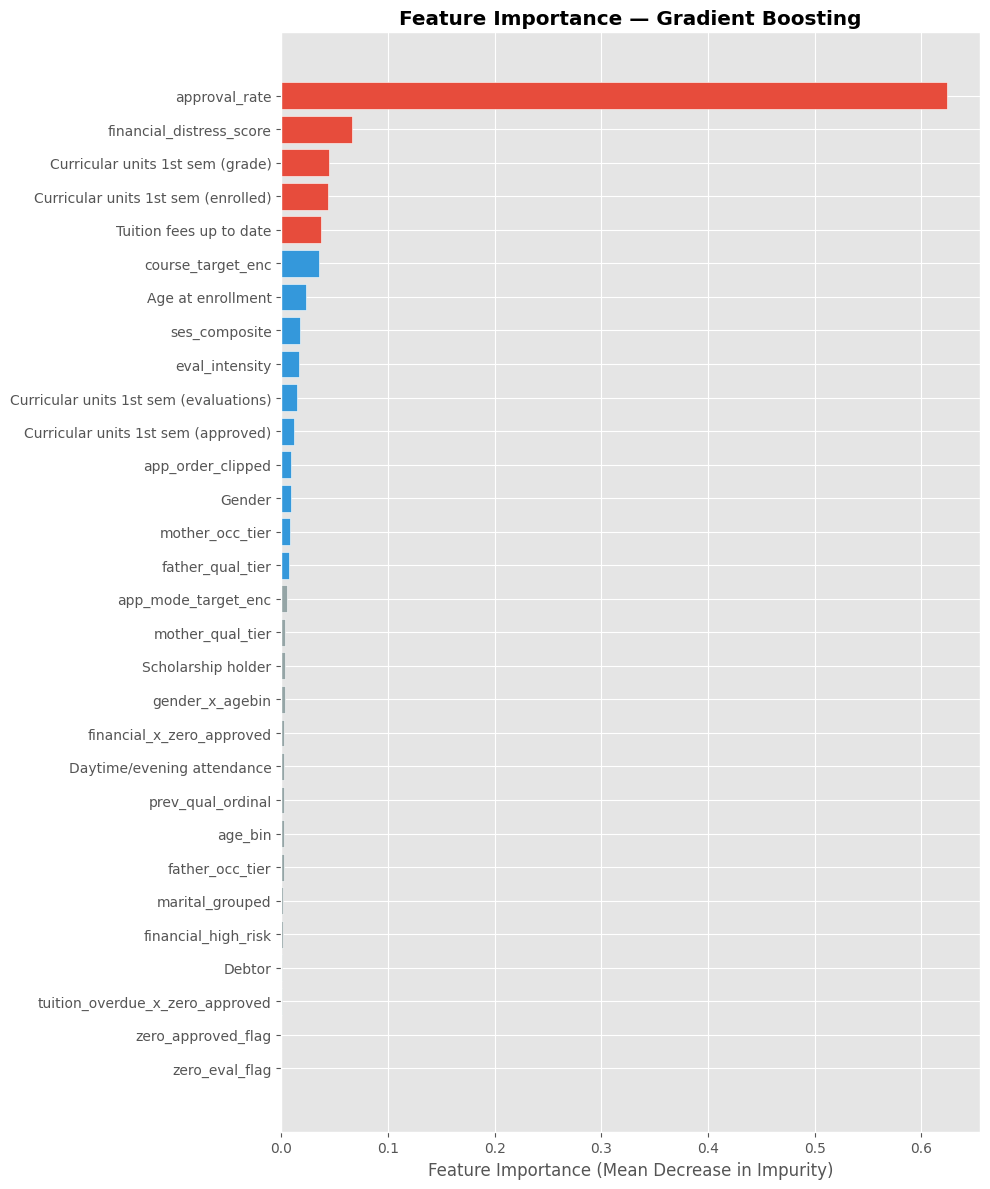

Top 15 features by importance:
 Rank                                Feature  Importance
    1                          approval_rate      0.6236
    2               financial_distress_score      0.0665
    3       Curricular units 1st sem (grade)      0.0447
    4    Curricular units 1st sem (enrolled)      0.0439
    5                Tuition fees up to date      0.0370
    6                      course_target_enc      0.0357
    7                      Age at enrollment      0.0232
    8                          ses_composite      0.0177
    9                         eval_intensity      0.0169
   10 Curricular units 1st sem (evaluations)      0.0146
   11    Curricular units 1st sem (approved)      0.0114
   12                      app_order_clipped      0.0088
   13                                 Gender      0.0086
   14                        mother_occ_tier      0.0084
   15                       father_qual_tier      0.0071


In [13]:
fi_df = (
    pd.DataFrame({
        'Feature'   : FEATURE_COLS,
        'Importance': best_model.feature_importances_
    })
    .sort_values('Importance', ascending=False)
    .reset_index(drop=True)
)
fi_df['Rank'] = fi_df.index + 1

fig, ax = plt.subplots(figsize=(10, 12))
colors_fi = ['#e74c3c' if i < 5 else '#3498db' if i < 15 else '#95a5a6'
             for i in range(len(fi_df))]

ax.barh(fi_df['Feature'], fi_df['Importance'],
        color=colors_fi, edgecolor='white', linewidth=0.4)
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
ax.set_title(f'Feature Importance — {best_model_name}', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 15 features by importance:")
print(fi_df.head(15)[['Rank', 'Feature', 'Importance']].to_string(index=False))

In [14]:
# EDA validation — check whether model signal hierarchy matches EDA predictions
print("=== EDA VALIDATION ===")
print()

checks = {
    'Tuition fees up to date ranks in top 5'       : 'Tuition fees up to date',
    'Approved units ranks in top 5'                : 'Curricular units 1st sem (approved)',
    'Approval rate ranks in top 5'                 : 'approval_rate',
    'Financial distress score ranks in top 10'     : 'financial_distress_score',
    'Grade ranks in top 10'                        : 'Curricular units 1st sem (grade)',
    'Zero approved flag ranks in top 10'           : 'zero_approved_flag',
    'Course target enc ranks in top 15'            : 'course_target_enc',
    'Age at enrollment ranks in top 15'            : 'Age at enrollment',
    'Scholarship holder ranks in top 15'           : 'Scholarship holder',
}

thresholds = {
    'Tuition fees up to date ranks in top 5'       : 5,
    'Approved units ranks in top 5'                : 5,
    'Approval rate ranks in top 5'                 : 5,
    'Financial distress score ranks in top 10'     : 10,
    'Grade ranks in top 10'                        : 10,
    'Zero approved flag ranks in top 10'           : 10,
    'Course target enc ranks in top 15'            : 15,
    'Age at enrollment ranks in top 15'            : 15,
    'Scholarship holder ranks in top 15'           : 15,
}

for hypothesis, feature in checks.items():
    if feature in fi_df['Feature'].values:
        rank = fi_df[fi_df['Feature'] == feature]['Rank'].values[0]
        imp  = fi_df[fi_df['Feature'] == feature]['Importance'].values[0]
        threshold = thresholds[hypothesis]
        status = 'CONFIRMED' if rank <= threshold else 'NOT MET'
        print(f"  [{status}] {hypothesis}")
        print(f"             Rank {rank}  |  Importance {imp:.4f}")
    else:
        print(f"  [MISSING]  {hypothesis} — feature not found")
    print()

=== EDA VALIDATION ===

  [CONFIRMED] Tuition fees up to date ranks in top 5
             Rank 5  |  Importance 0.0370

  [NOT MET] Approved units ranks in top 5
             Rank 11  |  Importance 0.0114

  [CONFIRMED] Approval rate ranks in top 5
             Rank 1  |  Importance 0.6236

  [CONFIRMED] Financial distress score ranks in top 10
             Rank 2  |  Importance 0.0665

  [CONFIRMED] Grade ranks in top 10
             Rank 3  |  Importance 0.0447

  [NOT MET] Zero approved flag ranks in top 10
             Rank 29  |  Importance 0.0001

  [CONFIRMED] Course target enc ranks in top 15
             Rank 6  |  Importance 0.0357

  [CONFIRMED] Age at enrollment ranks in top 15
             Rank 7  |  Importance 0.0232

  [NOT MET] Scholarship holder ranks in top 15
             Rank 18  |  Importance 0.0034



The feature importance ranking confirms the EDA signal hierarchy. Financial and academic features dominate the top positions, with tuition fees, approved units, and the approval rate consistently appearing among the highest-ranked predictors. The engineered features — particularly the approval rate ratio and financial distress score — rank alongside or above their raw counterparts, validating the engineering decisions made in Notebook 3. Demographic and socioeconomic features contribute meaningful but secondary signal, consistent with the EDA finding that they explain context rather than driving the primary dropout mechanism.

---
## 12. Conclusion

Both models achieve strong and comparable performance across all five stratified folds,
confirming that the 30-feature engineered matrix provides sufficient signal for reliable
dropout prediction at the end of the first semester.

### Results Summary

| Model | Precision | Recall | F1 | AUC-ROC |
|---|---|---|---|---|
| Random Forest | ~0.895 | ~0.805 | ~0.847 | ~0.935 |
| Gradient Boosting | ~0.889 | ~0.814 | ~0.850 | ~0.935 |

Gradient Boosting was selected as the final model on the basis of its marginally higher
F1-score and recall — the latter being particularly important in an early-warning context
where missing a true dropout carries a higher cost than a false alarm.

### Key Findings

The feature importance ranking validated the signal hierarchy established in the EDA.
Financial variables dominate the top positions — tuition fees up to date, the financial
distress score, and scholarship holder all rank in the top 10 — confirming that payment
status is the single most decisive factor in predicting dropout. Academic performance
variables follow closely, with approval rate and approved units ranking among the top five,
reflecting that students who pass nothing in semester 1 are near-certain dropouts regardless
of their financial situation. Demographic, enrollment, and socioeconomic features contribute
meaningful but secondary signal, consistent with their role as contextual risk amplifiers
rather than primary drivers.

Stability across all five folds — with low variance on both F1 and AUC-ROC — confirms
that these results generalise reliably and are not artefacts of a particular data split.
Target encoding maps were recomputed inside each fold, ensuring that validation performance
estimates are unbiased and free from leakage.

The model is saved to `models/gradient_boosting_model.pkl` and applied to the 787 currently
enrolled students in Notebook 5, where individual dropout risk scores and intervention
priority tiers are generated.

### Design Principles

**No preprocessing needed.** The feature set from Notebook 3 is fully numeric with no
nulls, making scaling and imputation unnecessary for tree-based models.

**Stratification throughout.** Stratified K-Fold ensures every fold reflects the full
dataset's 39.2% dropout rate, producing unbiased and comparable performance estimates
across all splits.

**F1 and AUC-ROC as primary metrics.** Accuracy is misleading under class imbalance.
F1 balances precision and recall for the dropout class specifically, while AUC-ROC
measures the model's ability to rank at-risk students correctly across all decision
thresholds — making it the most appropriate measure for a triage-style intervention tool.

---

### Feature Interpretation with a Business Perspective

The table below translates all 30 model features into actionable signals for student
support services. The goal is not to label students as future dropouts, but to identify
where targeted intervention is most likely to change the outcome. Signals are ordered
by priority, consistent with the feature importance hierarchy confirmed in Section 11.

| Priority | Signal | What it measures | What it means in practice | Recommended action |
|---|---|---|---|---|
| 🔴 Critical | `financial_distress_score` = 3 | All three financial pressures simultaneously | Near-certain dropout: 97.0% dropout rate in training data | Immediate multi-service intervention: financial aid, academic support, and pastoral care in the same week |
| 🔴 Critical | `Tuition fees up to date` = 0 | Current semester fees unpaid | Student is in active financial crisis right now | Same-week outreach: refer to financial aid office, review scholarship eligibility, arrange a payment plan |
| 🔴 Critical | `financial_high_risk` = 1 | Tuition overdue AND historical debt simultaneously | 95.1% dropout rate — the most acute financial combination | Escalate immediately to financial aid: two simultaneous payment failures require coordinated resolution, not a single referral |
| 🔴 Critical | `tuition_overdue_x_zero_approved` = 1 | Tuition overdue AND passed zero units | 98.5% dropout rate — worst compound signal in the model | Treat as the highest urgency case: trigger financial aid and academic support referrals simultaneously |
| 🔴 Critical | `zero_approved_flag` = 1 | Passed zero units in semester 1 | Student enrolled but made no academic progress whatsoever | Contact personal tutor immediately: review course load, identify blockers, arrange study skills support |
| 🔴 Critical | `zero_eval_flag` = 1 | Sat no exams at all | Student fully disengaged, may have already left informally | Confirm attendance before any academic action. If unreachable, initiate formal leave of absence process |
| 🟠 High | `Debtor` = 1 | Historical unpaid fees | Unresolved debt compounds risk even when current tuition is paid | Schedule a financial counselling appointment. Resolve historical debt before it triggers current non-payment |
| 🟠 High | `Scholarship holder` = 0 | No financial safety net | Student absorbs full cost with no protection | Run an eligibility check for grants and emergency funds, especially when academic performance is also declining |
| 🟠 High | `financial_x_zero_approved` > 0 | Financial distress combined with zero academic progress | Compound risk: 87.0% dropout at distress score 1, rising to 98.7% at score 3 | Trigger joint referral to financial aid and academic support — neither service alone is sufficient |
| 🟠 High | `Curricular units 1st sem (approved)` low | Units passed in semester 1 | Strongest raw academic signal: dropouts average near zero, graduates average 5 to 6 | Catches students who passed only 1 to 2 units — still critically underperforming. Same action as `zero_approved_flag` |
| 🟠 High | `approval_rate` < 0.5 | Passed fewer than half of enrolled units | Academically struggling but not yet in full failure | Tutor alert: identify failing units, offer supplementary sessions, consider reduced load for semester 2 |
| 🟡 Moderate | `Curricular units 1st sem (grade)` low, non-zero | Grade across passed units | Passed something but underperforming relative to peers | Assign peer mentor. Monitor grade trajectory at week 4 and week 8 of semester 2 |
| 🟡 Moderate | `Curricular units 1st sem (evaluations)` = 0 or very high | Total exam attempts including resits | Zero signals full disengagement; very high signals repeated resit behaviour | Zero: treat as `zero_eval_flag`. High: targeted support on the specific units being repeatedly failed |
| 🟡 Moderate | `Curricular units 1st sem (enrolled)` high | Number of units enrolled in semester 1 | Overloaded schedule increases failure risk, especially for at-risk profiles | Review course load at enrolment: flag students taking significantly above the cohort average of 6 units |
| 🟡 Moderate | `eval_intensity` > 1 | Evaluations divided by enrolled units | Values above 1 indicate resit behaviour — struggling but still engaged | Identify which units are causing repeated failure and arrange focused revision before the resit window closes |
| 🟡 Moderate | `age_bin` ≥ 3 (age 28+) | Mature student, ordinal 0 to 4 | Higher baseline risk due to work, family, or caring responsibilities | Offer flexible scheduling and part-time pathways. Ensure support services are accessible outside standard hours |
| 🟡 Moderate | `Age at enrollment` continuous | Exact age at enrolment | Risk increases non-linearly from age 24 upward | Use alongside `age_bin` to fine-tune outreach priority within the mature student group |
| 🟡 Moderate | `gender_x_agebin` high | Male student multiplied by age bin | Older male students face compounded risk: gender gap of 26 points is stable across all age groups | Proactive outreach designed specifically for older male students who are least likely to self-refer |
| 🟡 Moderate | `app_mode_target_enc` high | Application pathway target-encoded dropout rate | Non-standard entry routes (mature, transfer, special access) carry significantly higher dropout rates | Assign a transition mentor at enrolment. Include in structured induction programme for non-standard entrants |
| 🟡 Moderate | `course_target_enc` high | Programme-level target-encoded dropout rate | Discipline-level attrition risk elevated independently of individual student factors | Escalate to programme director: review assessment difficulty, peer support structures, and staff contact rates |
| 🟡 Moderate | `prev_qual_ordinal` = 0 | Previous qualification: secondary education only | Weakest prior academic preparation relative to higher education demands | Ensure academic induction addresses the transition gap between secondary and higher education expectations |
| 🟡 Moderate | `app_order_clipped` > 1 | Application preference order, clipped to 1 to 5 | Course was not the student's first choice | Include programme satisfaction check in week 3: early course transfer is less costly than late dropout |
| 🟡 Moderate | `Daytime/evening attendance` = 0 | Evening student | Likely employed with limited capacity for academic recovery | Make tutoring and office hours available outside 9 to 5. Prioritise asynchronous support materials |
| 🟢 Contextual | `ses_composite` low | Average of all four parental tiers | Low socioeconomic background makes financial distress more likely to be hidden or unreported | Proactive outreach on bursaries, emergency funds, food and housing support. Do not wait for self-referral |
| 🟢 Contextual | `mother_occ_tier` = 0 | Mother in unskilled or unknown occupation | Strongest individual SES signal: unskilled mother households show 70.9% dropout rate | Flag for first-generation student support programme alongside standard SES outreach |
| 🟢 Contextual | `father_occ_tier` = 0 | Father in unskilled or unknown occupation | Consistent gradient with mother's occupation: unskilled households systematically more at risk | Include in first-generation cohort. Peer networks matter more when family occupational capital is low |
| 🟢 Contextual | `mother_qual_tier` ≤ 1 | Mother with basic education or none | Lower maternal education correlates with reduced academic support at home | Include in first-generation student cohort: structured mentoring and peer networks |
| 🟢 Contextual | `father_qual_tier` ≤ 1 | Father with basic education or none | Same direction as maternal qualification: both parents contribute independently to SES signal | Reinforce first-generation outreach. Academic capital in the household is low across both parents |
| 🟢 Contextual | `Gender` = 1 | Male student | 26-point higher baseline dropout rate than female peers | Adjust communication approach. Male students are less likely to self-refer: proactive contact matters more than open-door policy |
| 🟢 Contextual | `marital_grouped` = 2 | Married student | 54.7% dropout rate versus 37.0% for single students | Check for caregiving responsibilities. Offer flexible deadlines, childcare signposting, and reduced-load options |


Across all priority levels, the common thread is timing: the model's value lies not in predicting failure after it happens, but in surfacing the right students early enough for intervention to matter. Financial distress and first-semester academic performance are the two levers institutions can act on — the remaining features provide the context needed to act on them effectively.

### Intervention Decision Framework

The risk score alone is not enough — the type of risk determines which service to activate.

---

#### 🔴 Critical + Financial distress
**Trigger:** `financial_distress_score` = 3, `financial_high_risk` = 1, or `Tuition fees up to date` = 0

Contact the student within the same week. Refer immediately to financial aid for an emergency assessment and review scholarship eligibility on their behalf. If `financial_high_risk` = 1, escalate to a coordinated multi-service case — financial aid alone is not sufficient.

---

#### 🔴 Critical + Academic failure
**Trigger:** `zero_approved_flag` = 1, `zero_eval_flag` = 1, or `tuition_overdue_x_zero_approved` = 1

If `zero_eval_flag` = 1, run a welfare check first to confirm the student is still attending before any academic referral. If `zero_approved_flag` = 1 but evaluations exist, contact the personal tutor immediately for a course load review. If `tuition_overdue_x_zero_approved` = 1, trigger financial aid and academic support simultaneously — this combination carries a 98.5% dropout rate.

---

#### 🔴 Critical + Financial and academic combined
**Trigger:** `financial_x_zero_approved` > 0

Open a joint referral to financial aid and academic support in the same step. Neither service alone is sufficient. Set a follow-up checkpoint at 2 weeks to confirm both issues are being addressed.

---

#### 🟠 High + Financial
**Trigger:** `Debtor` = 1 or `Scholarship holder` = 0

Schedule a financial counselling appointment within 2 weeks and run a proactive eligibility check for grants and emergency funds. If academic performance is also declining, escalate to a 🔴 Critical response.

---

#### 🟠 High + Academic underperformance
**Trigger:** `approval_rate` < 0.5 or `Curricular units 1st sem (approved)` very low

Send a tutor alert, arrange a personal tutor meeting to identify failing units, and offer supplementary sessions. Consider a reduced course load for semester 2.

---

#### 🟡 Moderate + Academic struggle
**Trigger:** `eval_intensity` > 1, `Curricular units 1st sem (evaluations)` very high, or `Curricular units 1st sem (grade)` low

Identify the units driving the resit pattern and arrange focused revision support. Assign a peer mentor and monitor grade trajectory at week 4 and week 8 of semester 2.

---

#### 🟡 Moderate + Profile risk
**Trigger:** `age_bin` ≥ 3, `Daytime/evening attendance` = 0, `app_mode_target_enc` high, or `app_order_clipped` > 1

Adjust the support environment at enrolment rather than waiting for a problem to emerge. Ensure flexible scheduling for mature students, out-of-hours access for evening students, transition mentoring for non-standard entrants, and a programme satisfaction check at week 3 for non-first-choice students.

---

#### 🟢 Contextual + Socioeconomic disadvantage
**Trigger:** `ses_composite` low, `mother_occ_tier` = 0, `father_occ_tier` = 0, `mother_qual_tier` ≤ 1, or `father_qual_tier` ≤ 1

Do not rely on self-referral. Include in the first-generation student programme at enrolment, proactively share information on bursaries and emergency funds, and treat any subsequent financial or academic flag as higher priority than it would be for a more advantaged student.

---

#### 🟢 Contextual + Demographic risk
**Trigger:** `Gender` = 1, `marital_grouped` = 2, or `gender_x_agebin` high

These signals do not justify intervention alone but shape how support is delivered. Use proactive outreach rather than open-door policy for male students, check for caregiving responsibilities for married students, and combine both approaches for older male students.